In [1]:
import os
import json
import time
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)

In [2]:
XGB_AVAILABLE = False
SHAP_AVAILABLE = False
LIME_AVAILABLE = False
ELI5_AVAILABLE = False

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost is available.")
except Exception as e:
    print("XGBoost not available.")
    print("Reason:", str(e))

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP is available.")
except Exception as e:
    print("SHAP not available.")
    print("Reason:", str(e))

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
    print("LIME is available.")
except Exception as e:
    print("LIME not available.")
    print("Reason:", str(e))

try:
    import eli5
    from eli5.sklearn import PermutationImportance
    ELI5_AVAILABLE = True
    print("ELI5 is available.")
except Exception as e:
    print("ELI5 not available.")
    print("Reason:", str(e))

XGBoost is available.
SHAP is available.
LIME is available.
ELI5 is available.


In [3]:
TRAIN_PATH = r"C:\Users\User\Desktop\Data\train_forecast24_undersampled005_patientaware.csv"
VAL_PATH   = r"C:\Users\User\Desktop\Data\val_forecast24_balanced20.csv"
TEST_PATH  = r"C:\Users\User\Desktop\Data\test_forecast24_balanced20.csv"

BASE_OUTPUT_DIR = r"C:\Users\User\Desktop\Data\sepsis_xgboost_lujain"
os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

print("Output folder:", BASE_OUTPUT_DIR)

Output folder: C:\Users\User\Desktop\Data\sepsis_xgboost_lujain


In [4]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (45717, 19)
Val shape: (51082, 18)
Test shape: (53029, 18)


In [5]:
print("Train columns:")
print(train_df.columns.tolist())

Train columns:
['new_id', 'seconds_since_birth', 'mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 'sex', 'birth_weight', 'y_forecast_24h', 'patient_label']


In [6]:
PATIENT_COL = "new_id"
TIME_COL = "seconds_since_birth"
TARGET_COL = "y_forecast_24h"

EXCLUDED_FROM_TRAINING = [
    "new_id",
    "patient_label",
    "seconds_since_birth",
    "y_forecast_24h"
]

FEATURE_COLS = [
    "mean_hr",
    "sd_hr",
    "skewness_hr",
    "kurtosis_hr",
    "mean_spo2",
    "sd_spo2",
    "skewness_spo2",
    "kurtosis_spo2",
    "min_xc_hr_spo2",
    "max_xc_hr_spo2",
    "birth_weight"
]

OPTIONAL_EVENT_COL = "sepsis_window"
OPTIONAL_BLACKOUT_COL = "blackout_window"

print("Excluded from training only:")
print(EXCLUDED_FROM_TRAINING)

print("\nFeatures used for training:")
print(FEATURE_COLS)

print("\nNumber of training features:", len(FEATURE_COLS))

Excluded from training only:
['new_id', 'patient_label', 'seconds_since_birth', 'y_forecast_24h']

Features used for training:
['mean_hr', 'sd_hr', 'skewness_hr', 'kurtosis_hr', 'mean_spo2', 'sd_spo2', 'skewness_spo2', 'kurtosis_spo2', 'min_xc_hr_spo2', 'max_xc_hr_spo2', 'birth_weight']

Number of training features: 11


In [7]:
print("Missing values in selected training features (train):")
print(train_df[FEATURE_COLS].isnull().sum())

print("\nTarget distribution in TRAIN:")
print(train_df[TARGET_COL].value_counts(dropna=False))

print("\nTarget distribution in VAL:")
print(val_df[TARGET_COL].value_counts(dropna=False))

print("\nTarget distribution in TEST:")
print(test_df[TARGET_COL].value_counts(dropna=False))

Missing values in selected training features (train):
mean_hr           0
sd_hr             0
skewness_hr       0
kurtosis_hr       0
mean_spo2         0
sd_spo2           0
skewness_spo2     0
kurtosis_spo2     0
min_xc_hr_spo2    0
max_xc_hr_spo2    0
birth_weight      0
dtype: int64

Target distribution in TRAIN:
y_forecast_24h
1    30178
0    15539
Name: count, dtype: int64

Target distribution in VAL:
y_forecast_24h
0    45295
1     5787
Name: count, dtype: int64

Target distribution in TEST:
y_forecast_24h
0    45347
1     7682
Name: count, dtype: int64


In [8]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].astype(int).copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].astype(int).copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].astype(int).copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (45717, 11)
X_val: (51082, 11)
X_test: (53029, 11)


In [9]:
run_config = {
    "train_path": TRAIN_PATH,
    "val_path": VAL_PATH,
    "test_path": TEST_PATH,
    "patient_col": PATIENT_COL,
    "time_col": TIME_COL,
    "target_col": TARGET_COL,
    "excluded_from_training_only": EXCLUDED_FROM_TRAINING,
    "feature_cols": FEATURE_COLS,
    "window_logic": "If any single positive window is detected, patient gets an alert.",
    "seed": SEED
}

with open(os.path.join(BASE_OUTPUT_DIR, "run_config.json"), "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2, ensure_ascii=False)

print("Run configuration saved.")

Run configuration saved.


In [10]:
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_COLS)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=FEATURE_COLS)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=FEATURE_COLS)

joblib.dump(imputer, os.path.join(BASE_OUTPUT_DIR, "imputer.pkl"))

print("Imputation complete.")
X_train_imp.head()

Imputation complete.


,mean_hr,sd_hr,skewness_hr,kurtosis_hr,mean_spo2,sd_spo2,skewness_spo2,kurtosis_spo2,min_xc_hr_spo2,max_xc_hr_spo2,birth_weight
0,158.893333,10.448566,-1.727692,11.314256,98.683333,3.839992,-3.502019,16.072992,-0.295154,0.139075,1440.0
1,149.423333,12.866076,0.216538,2.562530,96.003333,6.667195,-1.876723,5.379521,-0.435035,-0.070159,1440.0
2,152.153333,5.142435,0.322412,3.660565,98.763333,1.725470,-2.562193,11.400890,-0.236994,0.056803,1440.0
3,160.836667,10.698826,-0.126693,3.607137,98.993333,1.583767,-1.840916,5.834654,-0.143956,0.032089,1440.0
4,144.216667,8.492160,0.446179,2.529488,96.120000,3.761128,-1.842055,5.942367,-0.423823,-0.041081,1440.0


In [11]:
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def find_best_threshold(y_true, y_prob, beta=2, step=0.01):
    thresholds = np.arange(step, 1.0, step)
    best_thr = 0.5
    best_score = -1

    for thr in thresholds:
        y_pred = (np.asarray(y_prob) >= thr).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if score > best_score:
            best_score = score
            best_thr = thr

    return float(best_thr), float(best_score)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "ppv": float(precision_score(y_true, y_pred, zero_division=0)),
        "npv": float(tn / (tn + fn)) if (tn + fn) > 0 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn)
    }


def compute_metrics_from_binary(y_true, y_pred, y_prob=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "ppv": float(precision_score(y_true, y_pred, zero_division=0)),
        "npv": float(tn / (tn + fn)) if (tn + fn) > 0 else 0.0,
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn)
    }

    if y_prob is not None:
        out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
        out["pr_auc"] = float(average_precision_score(y_true, y_prob))
        out["brier"] = float(brier_score_loss(y_true, y_prob))

    return out

In [12]:
def make_prediction_df(source_df, y_prob, threshold):
    out = source_df[[PATIENT_COL, TIME_COL, TARGET_COL]].copy()
    out["y_prob"] = np.asarray(y_prob)
    out["y_pred"] = (out["y_prob"] >= threshold).astype(int)

    if OPTIONAL_EVENT_COL in source_df.columns:
        out[OPTIONAL_EVENT_COL] = source_df[OPTIONAL_EVENT_COL].values

    if OPTIONAL_BLACKOUT_COL in source_df.columns:
        out[OPTIONAL_BLACKOUT_COL] = source_df[OPTIONAL_BLACKOUT_COL].values

    return out


def patient_level_evaluation(pred_df, pred_col="y_pred", prob_col="y_prob"):
    patient_df = pred_df.groupby(PATIENT_COL).agg(
        patient_true=(TARGET_COL, "max"),
        patient_pred=(pred_col, "max"),
        max_prob=(prob_col, "max"),
        n_windows=(TARGET_COL, "size")
    ).reset_index()

    y_true = patient_df["patient_true"].astype(int).values
    y_pred = patient_df["patient_pred"].astype(int).values

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results = {
        "n_patients": int(len(patient_df)),
        "patient_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "patient_specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "patient_ppv": float(precision_score(y_true, y_pred, zero_division=0)),
        "patient_npv": float(tn / (tn + fn)) if (tn + fn) > 0 else 0.0,
        "patient_accuracy": float(accuracy_score(y_true, y_pred)),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn)
    }

    return patient_df, results


def compute_first_alerts(pred_df, alert_col="y_pred"):
    df = pred_df.copy().sort_values([PATIENT_COL, TIME_COL])
    event_col = OPTIONAL_EVENT_COL if OPTIONAL_EVENT_COL in df.columns else TARGET_COL

    rows = []
    for patient_id, g in df.groupby(PATIENT_COL):
        g = g.sort_values(TIME_COL)

        event_rows = g[g[event_col] == 1]
        alert_rows = g[g[alert_col] == 1]

        t_event = event_rows[TIME_COL].min() if len(event_rows) > 0 else np.nan
        t_alert = alert_rows[TIME_COL].min() if len(alert_rows) > 0 else np.nan

        lead_hours = np.nan
        if pd.notna(t_event) and pd.notna(t_alert):
            lead_hours = (t_event - t_alert) / 3600.0

        rows.append({
            "patient_id": patient_id,
            "t_event_seconds": t_event,
            "t_alert_seconds": t_alert,
            "lead_hours": lead_hours,
            "event_detected": int(pd.notna(t_event) and pd.notna(t_alert) and (t_alert <= t_event)),
            "has_event": int(pd.notna(t_event)),
            "has_alert": int(pd.notna(t_alert))
        })

    return pd.DataFrame(rows)


def summarize_alerts(first_alerts_df):
    event_patients = first_alerts_df[first_alerts_df["has_event"] == 1].copy()

    if len(event_patients) == 0:
        return {
            "n_event_patients": 0,
            "n_detected_event_patients": 0,
            "event_detection_rate": 0.0,
            "median_lead_hours_detected": None,
            "mean_lead_hours_detected": None
        }

    detected = event_patients[event_patients["event_detected"] == 1].copy()
    lead_vals = detected["lead_hours"].dropna()

    return {
        "n_event_patients": int(len(event_patients)),
        "n_detected_event_patients": int(len(detected)),
        "event_detection_rate": float(len(detected) / len(event_patients)),
        "median_lead_hours_detected": float(lead_vals.median()) if len(lead_vals) > 0 else None,
        "mean_lead_hours_detected": float(lead_vals.mean()) if len(lead_vals) > 0 else None
    }

In [13]:
def plot_confusion_matrix_binary(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def plot_roc_curve(y_true, y_prob, title, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def plot_pr_curve(y_true, y_prob, title, save_path):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {average_precision_score(y_true, y_prob):.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def plot_calibration_curve(y_true, y_prob, title, save_path, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="uniform")

    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

In [14]:
def apply_ema_per_patient(pred_df, alpha=0.3):
    df = pred_df.copy().sort_values([PATIENT_COL, TIME_COL])
    out_parts = []

    for patient_id, g in df.groupby(PATIENT_COL):
        g = g.sort_values(TIME_COL).copy()
        probs = g["y_prob"].values

        ema_vals = []
        current = probs[0]
        for p in probs:
            current = alpha * p + (1 - alpha) * current
            ema_vals.append(current)

        g["y_prob_ema"] = ema_vals
        out_parts.append(g)

    return pd.concat(out_parts, axis=0).reset_index(drop=True)


def apply_k_of_n_rule(pred_df, prob_col="y_prob_ema", threshold=0.5, k=2, n=3):
    df = pred_df.copy().sort_values([PATIENT_COL, TIME_COL])
    out_parts = []

    for patient_id, g in df.groupby(PATIENT_COL):
        g = g.sort_values(TIME_COL).copy()
        base_preds = (g[prob_col].values >= threshold).astype(int)

        smoothed_preds = []
        for i in range(len(base_preds)):
            start = max(0, i - n + 1)
            window = base_preds[start:i+1]
            smoothed_preds.append(int(window.sum() >= k))

        g["y_pred_post"] = smoothed_preds
        out_parts.append(g)

    return pd.concat(out_parts, axis=0).reset_index(drop=True)


def apply_refractory_period(pred_df, refractory_steps=3):
    df = pred_df.copy().sort_values([PATIENT_COL, TIME_COL])
    out_parts = []

    for patient_id, g in df.groupby(PATIENT_COL):
        g = g.sort_values(TIME_COL).copy()
        preds = g["y_pred_post"].values

        final_alerts = np.zeros_like(preds)
        last_alert_idx = -999999

        for i, p in enumerate(preds):
            if p == 1 and (i - last_alert_idx) > refractory_steps:
                final_alerts[i] = 1
                last_alert_idx = i

        g["y_alert_final"] = final_alerts
        out_parts.append(g)

    return pd.concat(out_parts, axis=0).reset_index(drop=True)

In [15]:
if not XGB_AVAILABLE:
    raise ImportError("XGBoost is not installed. Please install it first.")

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    random_state=SEED,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device="cuda"
)

print("XGBoost configured for GPU.")
print("scale_pos_weight =", scale_pos_weight)

XGBoost configured for GPU.
scale_pos_weight = 0.5149115249519518


In [16]:
start_train = time.time()

xgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_train_imp, y_train), (X_val_imp, y_val)],
    verbose=True
)

train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

[0]	validation_0-logloss:0.68323	validation_0-auc:0.74040	validation_1-logloss:0.68993	validation_1-auc:0.65486
[1]	validation_0-logloss:0.67418	validation_0-auc:0.75787	validation_1-logloss:0.68740	validation_1-auc:0.67151
[2]	validation_0-logloss:0.66596	validation_0-auc:0.76593	validation_1-logloss:0.68562	validation_1-auc:0.66781
[3]	validation_0-logloss:0.65879	validation_0-auc:0.76873	validation_1-logloss:0.68555	validation_1-auc:0.65474
[4]	validation_0-logloss:0.65254	validation_0-auc:0.77114	validation_1-logloss:0.68543	validation_1-auc:0.65952
[5]	validation_0-logloss:0.64628	validation_0-auc:0.78217	validation_1-logloss:0.68052	validation_1-auc:0.66997
[6]	validation_0-logloss:0.63929	validation_0-auc:0.78683	validation_1-logloss:0.67888	validation_1-auc:0.67245
[7]	validation_0-logloss:0.63317	validation_0-auc:0.78710	validation_1-logloss:0.67816	validation_1-auc:0.67174
[8]	validation_0-logloss:0.62664	validation_0-auc:0.78917	validation_1-logloss:0.67708	validation_1-auc:

In [17]:
joblib.dump(xgb_model, os.path.join(BASE_OUTPUT_DIR, "xgboost_model.pkl"))
joblib.dump(FEATURE_COLS, os.path.join(BASE_OUTPUT_DIR, "feature_list.pkl"))

model_size_kb = os.path.getsize(os.path.join(BASE_OUTPUT_DIR, "xgboost_model.pkl")) / 1024.0

print("Model saved.")
print("Model size (KB):", model_size_kb)

Model saved.
Model size (KB): 312.2744140625


In [18]:
evals_result = xgb_model.evals_result()

history_df = pd.DataFrame({
    "round": np.arange(1, len(evals_result["validation_0"]["logloss"]) + 1),
    "train_logloss": evals_result["validation_0"]["logloss"],
    "val_logloss": evals_result["validation_1"]["logloss"],
    "train_auc": evals_result["validation_0"]["auc"],
    "val_auc": evals_result["validation_1"]["auc"]
})

history_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "training_history_per_round.csv"), index=False)
history_df.head()

,round,train_logloss,val_logloss,train_auc,val_auc
0,1,0.683235,0.689926,0.740399,0.654865
1,2,0.674178,0.687402,0.757873,0.671510
2,3,0.665963,0.685624,0.765927,0.667807
3,4,0.658789,0.685552,0.768733,0.654741
4,5,0.652541,0.685428,0.771142,0.659516


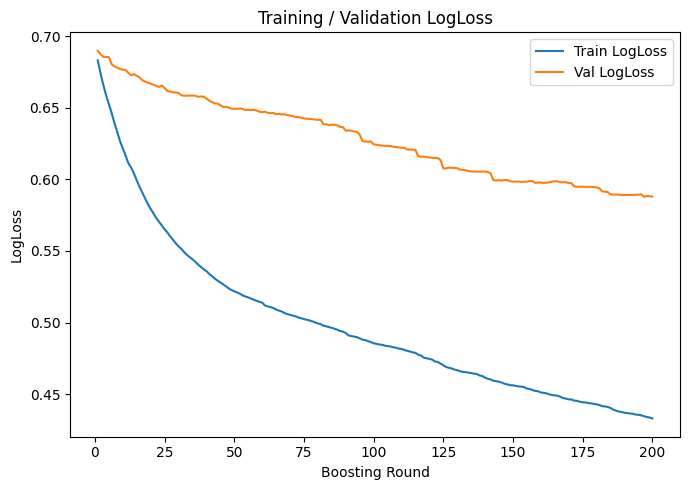

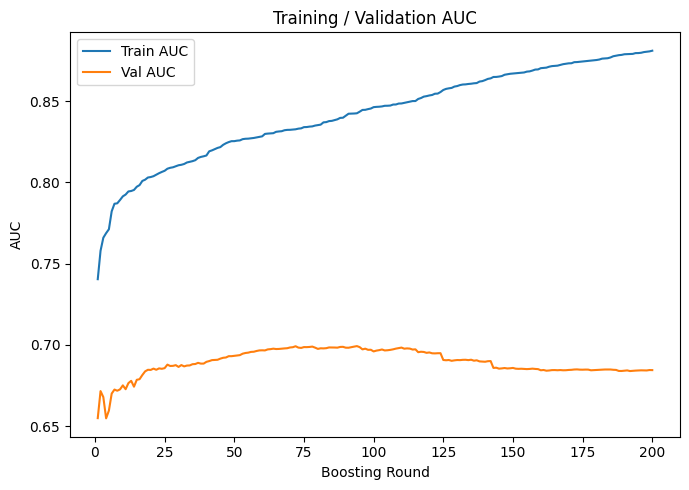

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(history_df["round"], history_df["train_logloss"], label="Train LogLoss")
plt.plot(history_df["round"], history_df["val_logloss"], label="Val LogLoss")
plt.xlabel("Boosting Round")
plt.ylabel("LogLoss")
plt.title("Training / Validation LogLoss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "logloss_per_round.png"), dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_df["round"], history_df["train_auc"], label="Train AUC")
plt.plot(history_df["round"], history_df["val_auc"], label="Val AUC")
plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.title("Training / Validation AUC")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "auc_per_round.png"), dpi=150)
plt.show()

In [20]:
round_metrics = []

for i in range(10, xgb_model.n_estimators + 1, 10):
    val_prob_round = xgb_model.predict_proba(X_val_imp, iteration_range=(0, i))[:, 1]
    thr_round, _ = find_best_threshold(y_val, val_prob_round, beta=2, step=0.05)
    metrics_round = compute_metrics(y_val, val_prob_round, threshold=thr_round)

    round_metrics.append({
        "round": i,
        "best_threshold": thr_round,
        "accuracy": metrics_round["accuracy"],
        "precision": metrics_round["precision"],
        "recall": metrics_round["recall"],
        "f1": metrics_round["f1"],
        "f2": metrics_round["f2"],
        "specificity": metrics_round["specificity"],
        "roc_auc": metrics_round["roc_auc"],
        "pr_auc": metrics_round["pr_auc"],
        "brier": metrics_round["brier"]
    })

    print(f"Round {i} | Acc={metrics_round['accuracy']:.4f} | F1={metrics_round['f1']:.4f} | F2={metrics_round['f2']:.4f}")

round_metrics_df = pd.DataFrame(round_metrics)
round_metrics_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "validation_metrics_per_round.csv"), index=False)

round_metrics_df.head()

Round 10 | Acc=0.5015 | F1=0.2657 | F2=0.4426
Round 20 | Acc=0.5599 | F1=0.2802 | F2=0.4503
Round 30 | Acc=0.5736 | F1=0.2806 | F2=0.4459
Round 40 | Acc=0.5795 | F1=0.2820 | F2=0.4462
Round 50 | Acc=0.5911 | F1=0.2845 | F2=0.4460
Round 60 | Acc=0.5314 | F1=0.2731 | F2=0.4471
Round 70 | Acc=0.5394 | F1=0.2755 | F2=0.4488
Round 80 | Acc=0.5440 | F1=0.2755 | F2=0.4472
Round 90 | Acc=0.5535 | F1=0.2777 | F2=0.4480
Round 100 | Acc=0.5105 | F1=0.2705 | F2=0.4489
Round 110 | Acc=0.5177 | F1=0.2727 | F2=0.4508
Round 120 | Acc=0.5246 | F1=0.2742 | F2=0.4513
Round 130 | Acc=0.5321 | F1=0.2755 | F2=0.4512
Round 140 | Acc=0.5350 | F1=0.2755 | F2=0.4502
Round 150 | Acc=0.5432 | F1=0.2775 | F2=0.4512
Round 160 | Acc=0.5441 | F1=0.2772 | F2=0.4504
Round 170 | Acc=0.5457 | F1=0.2777 | F2=0.4507
Round 180 | Acc=0.5487 | F1=0.2778 | F2=0.4498
Round 190 | Acc=0.5548 | F1=0.2790 | F2=0.4499
Round 200 | Acc=0.5568 | F1=0.2792 | F2=0.4496


,round,best_threshold,accuracy,precision,recall,f1,f2,specificity,roc_auc,pr_auc,brier
0,10,0.5,0.501488,0.159432,0.795922,0.265652,0.442561,0.463870,0.675036,0.189919,0.242078
1,20,0.5,0.559923,0.171979,0.756178,0.280225,0.450271,0.534849,0.684538,0.195635,0.237794
2,30,0.5,0.573607,0.173459,0.734059,0.280609,0.445863,0.553107,0.686390,0.198463,0.235275
3,40,0.5,0.579480,0.174830,0.729048,0.282028,0.446172,0.560371,0.689519,0.203112,0.234003
4,50,0.5,0.591069,0.177418,0.717643,0.284501,0.446022,0.574898,0.693208,0.204389,0.230934


In [21]:
start_val_inf = time.time()
val_prob = xgb_model.predict_proba(X_val_imp)[:, 1]
val_inference_time = time.time() - start_val_inf

start_test_inf = time.time()
test_prob = xgb_model.predict_proba(X_test_imp)[:, 1]
test_inference_time = time.time() - start_test_inf

print("Validation inference time:", val_inference_time)
print("Test inference time:", test_inference_time)

Validation inference time: 0.019934892654418945
Test inference time: 0.013998746871948242


In [22]:
best_thr, best_f2 = find_best_threshold(y_val, val_prob, beta=2, step=0.01)

threshold_info = {
    "best_threshold": best_thr,
    "best_validation_f2": best_f2,
    "selection_metric": "F2-score",
    "selection_set": "validation"
}

save_json(threshold_info, os.path.join(BASE_OUTPUT_DIR, "threshold_info.json"))
print(json.dumps(threshold_info, indent=2))

{
  "best_threshold": 0.4,
  "best_validation_f2": 0.4496155817529472,
  "selection_metric": "F2-score",
  "selection_set": "validation"
}


In [23]:
val_metrics_raw = compute_metrics(y_val, val_prob, threshold=best_thr)
test_metrics_raw = compute_metrics(y_test, test_prob, threshold=best_thr)

save_json(val_metrics_raw, os.path.join(BASE_OUTPUT_DIR, "val_metrics_window_level_raw.json"))
save_json(test_metrics_raw, os.path.join(BASE_OUTPUT_DIR, "test_metrics_window_level_raw.json"))

metrics_table_raw = pd.DataFrame([val_metrics_raw, test_metrics_raw], index=["Validation", "Test"])
metrics_table_raw = metrics_table_raw[[
    "threshold", "accuracy", "precision", "recall", "specificity",
    "f1", "f2", "ppv", "npv", "roc_auc", "pr_auc", "brier", "tp", "tn", "fp", "fn"
]]

display(metrics_table_raw)

,threshold,accuracy,precision,recall,specificity,f1,f2,ppv,npv,roc_auc,pr_auc,brier,tp,tn,fp,fn
Validation,0.4,0.556752,0.171148,0.757906,0.531052,0.279239,0.449616,0.171148,0.944962,0.684426,0.193114,0.206504,4386,24054,21241,1401
Test,0.4,0.555998,0.208369,0.737699,0.525217,0.324952,0.489167,0.208369,0.921996,0.688949,0.262241,0.214233,5667,23817,21530,2015


In [24]:
val_pred_df = make_prediction_df(val_df, val_prob, best_thr)
test_pred_df = make_prediction_df(test_df, test_prob, best_thr)

val_pred_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "val_predictions_patientwise.csv"), index=False)
test_pred_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "test_predictions_patientwise.csv"), index=False)

print("Raw prediction files saved.")

Raw prediction files saved.


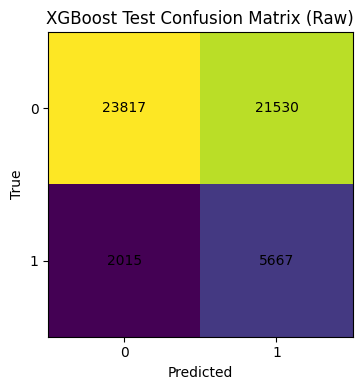

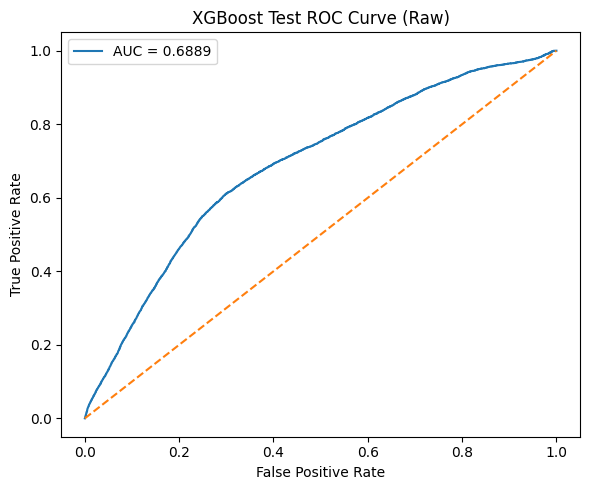

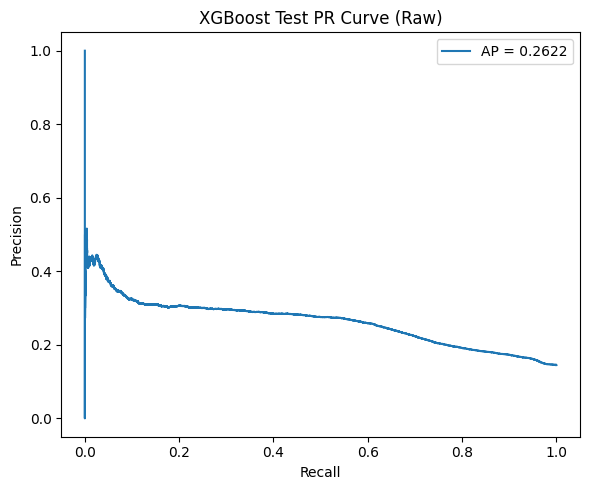

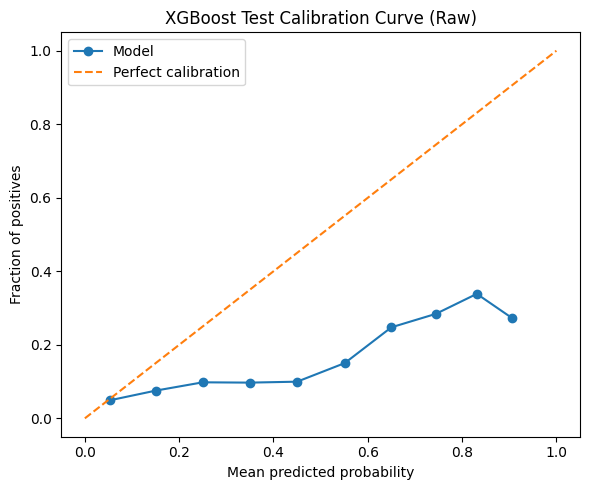

In [25]:
plot_confusion_matrix_binary(
    y_test,
    (test_prob >= best_thr).astype(int),
    title="XGBoost Test Confusion Matrix (Raw)",
    save_path=os.path.join(BASE_OUTPUT_DIR, "confusion_matrix_test_raw.png")
)

plot_roc_curve(
    y_test, test_prob,
    title="XGBoost Test ROC Curve (Raw)",
    save_path=os.path.join(BASE_OUTPUT_DIR, "roc_curve_test_raw.png")
)

plot_pr_curve(
    y_test, test_prob,
    title="XGBoost Test PR Curve (Raw)",
    save_path=os.path.join(BASE_OUTPUT_DIR, "pr_curve_test_raw.png")
)

plot_calibration_curve(
    y_test, test_prob,
    title="XGBoost Test Calibration Curve (Raw)",
    save_path=os.path.join(BASE_OUTPUT_DIR, "calibration_curve_test_raw.png")
)

In [26]:
xgb_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_gain": xgb_model.feature_importances_
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)

xgb_importance_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "feature_importance_xgboost.csv"), index=False)
display(xgb_importance_df)

,feature,importance_gain
0,mean_spo2,0.181465
1,skewness_hr,0.173965
2,birth_weight,0.149890
3,sd_hr,0.124839
4,kurtosis_spo2,0.095117
5,max_xc_hr_spo2,0.071089
6,mean_hr,0.057765
7,min_xc_hr_spo2,0.050145
8,kurtosis_hr,0.044243
9,sd_spo2,0.027939


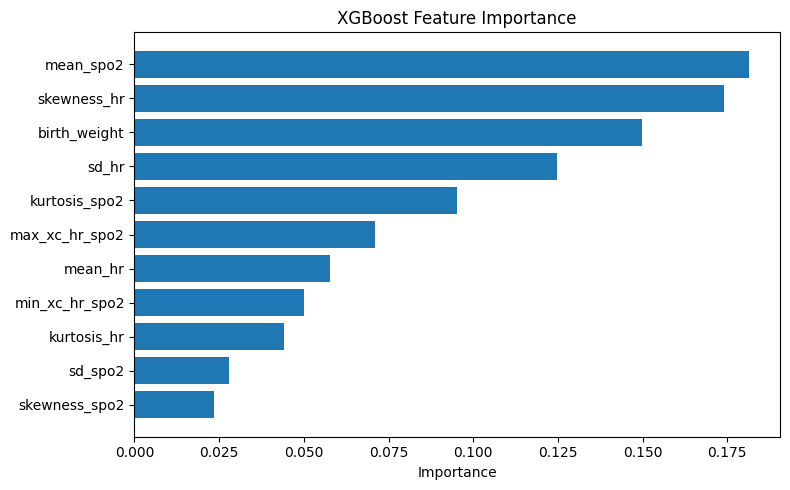

In [27]:
plt.figure(figsize=(8, 5))
plt.barh(xgb_importance_df["feature"], xgb_importance_df["importance_gain"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "feature_importance_xgboost.png"), dpi=150)
plt.show()

In [28]:
perm = permutation_importance(
    xgb_model,
    X_val_imp,
    y_val,
    n_repeats=10,
    random_state=SEED,
    scoring="f1"
)

perm_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "permutation_importance_val.csv"), index=False)
display(perm_df)

,feature,importance_mean,importance_std
0,sd_hr,0.052430,0.001945
1,skewness_hr,0.016816,0.001227
2,birth_weight,0.016739,0.001632
3,mean_spo2,0.012642,0.001615
4,max_xc_hr_spo2,0.009025,0.000933
5,mean_hr,0.008854,0.000728
6,kurtosis_spo2,0.007402,0.001457
7,min_xc_hr_spo2,0.000740,0.000677
8,skewness_spo2,0.000662,0.000310
9,kurtosis_hr,0.000564,0.000635


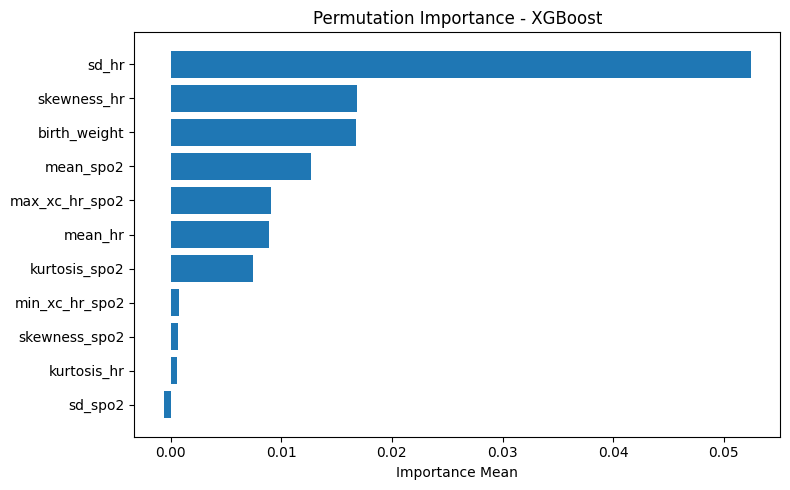

In [29]:
plt.figure(figsize=(8, 5))
plt.barh(perm_df["feature"], perm_df["importance_mean"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance - XGBoost")
plt.xlabel("Importance Mean")
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "permutation_importance_val.png"), dpi=150)
plt.show()

PermutationExplainer explainer: 201it [00:38,  5.24it/s]                         


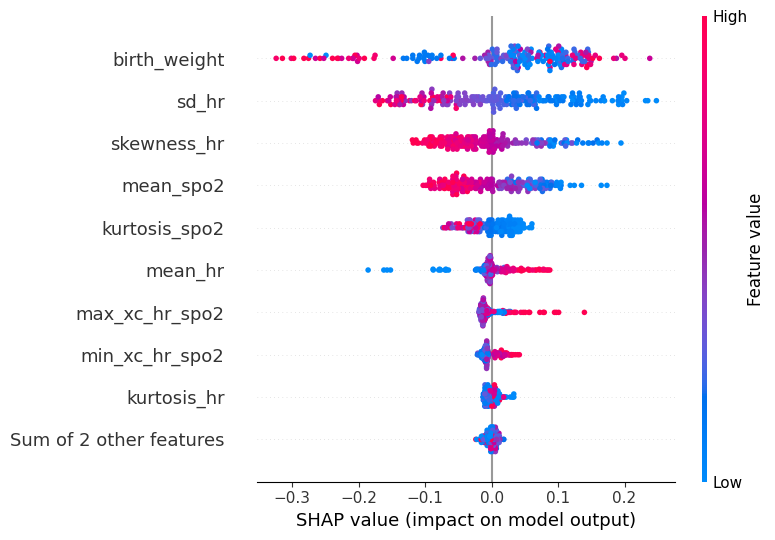

In [61]:
if SHAP_AVAILABLE:
    sample_size = min(200, len(X_val_imp))
    shap_sample = X_val_imp.sample(sample_size, random_state=SEED).copy()

    try:
        explainer = shap.Explainer(xgb_model.predict_proba, shap_sample)
        shap_values = explainer(shap_sample)

        shap.plots.beeswarm(shap_values[:, :, 1], show=False)
        plt.tight_layout()
        plt.savefig(
            os.path.join(BASE_OUTPUT_DIR, "shap_summary_plot.png"),
            dpi=150,
            bbox_inches="tight"
        )
        plt.show()

    except Exception as e:
        print("SHAP failed again.")
        print("Reason:", str(e))
else:
    print("SHAP not installed.")

In [62]:
if SHAP_AVAILABLE:
    try:
        shap_abs_mean = np.abs(shap_values.values[:, :, 1]).mean(axis=0)

        shap_df = pd.DataFrame({
            "feature": FEATURE_COLS,
            "mean_abs_shap": shap_abs_mean
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

        shap_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "shap_importance_table.csv"), index=False)
        display(shap_df)

    except Exception as e:
        print("Could not build SHAP table.")
        print("Reason:", str(e))

,feature,mean_abs_shap
0,birth_weight,0.099481
1,sd_hr,0.084399
2,skewness_hr,0.056189
3,mean_spo2,0.051550
4,kurtosis_spo2,0.026557
5,mean_hr,0.020921
6,max_xc_hr_spo2,0.016372
7,min_xc_hr_spo2,0.011993
8,kurtosis_hr,0.007059
9,sd_spo2,0.004546


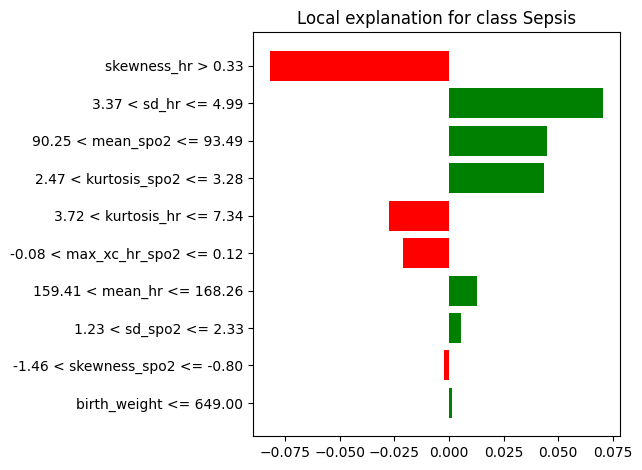

,feature,importance
0,skewness_hr > 0.33,-0.082043
1,3.37 < sd_hr <= 4.99,0.070717
2,90.25 < mean_spo2 <= 93.49,0.045103
3,2.47 < kurtosis_spo2 <= 3.28,0.043709
4,3.72 < kurtosis_hr <= 7.34,-0.027481
5,-0.08 < max_xc_hr_spo2 <= 0.12,-0.021001
6,159.41 < mean_hr <= 168.26,0.012834
7,1.23 < sd_spo2 <= 2.33,0.005599
8,-1.46 < skewness_spo2 <= -0.80,-0.002369
9,birth_weight <= 649.00,0.001220


In [31]:
if LIME_AVAILABLE:
    X_train_np = X_train_imp.values
    X_val_np = X_val_imp.values
    y_val_np = y_val.values

    lime_explainer = LimeTabularExplainer(
        training_data=X_train_np,
        feature_names=FEATURE_COLS,
        class_names=["No Sepsis", "Sepsis"],
        mode="classification",
        discretize_continuous=True,
        random_state=SEED
    )

    positive_indices = np.where(y_val_np == 1)[0]

    if len(positive_indices) > 0:
        sample_index = positive_indices[0]
        sample_instance = X_val_np[sample_index]

        exp = lime_explainer.explain_instance(
            data_row=sample_instance,
            predict_fn=xgb_model.predict_proba,
            num_features=10
        )

        fig = exp.as_pyplot_figure()
        plt.tight_layout()
        plt.savefig(os.path.join(BASE_OUTPUT_DIR, "lime_explanation_positive_case.png"), dpi=150, bbox_inches="tight")
        plt.show()

        lime_df = pd.DataFrame(exp.as_list(), columns=["feature", "importance"])
        lime_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "lime_feature_importance_positive_case.csv"), index=False)
        display(lime_df)
    else:
        print("No positive validation case found.")
else:
    print("LIME not installed.")

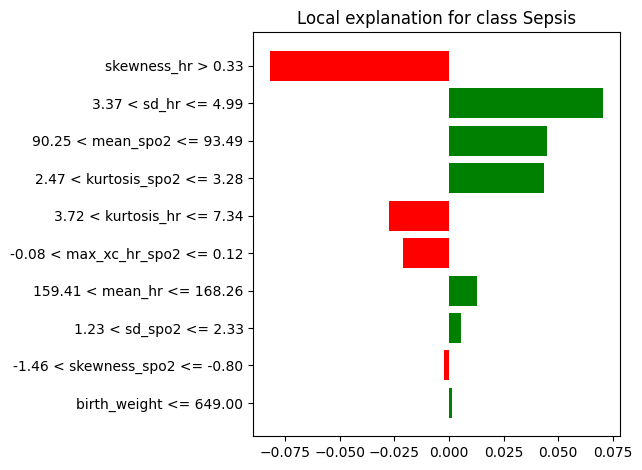

,feature,importance
0,skewness_hr > 0.33,-0.082043
1,3.37 < sd_hr <= 4.99,0.070717
2,90.25 < mean_spo2 <= 93.49,0.045103
3,2.47 < kurtosis_spo2 <= 3.28,0.043709
4,3.72 < kurtosis_hr <= 7.34,-0.027481
5,-0.08 < max_xc_hr_spo2 <= 0.12,-0.021001
6,159.41 < mean_hr <= 168.26,0.012834
7,1.23 < sd_spo2 <= 2.33,0.005599
8,-1.46 < skewness_spo2 <= -0.80,-0.002369
9,birth_weight <= 649.00,0.001220


In [32]:
if LIME_AVAILABLE:
    X_train_np = X_train_imp.values
    X_val_np = X_val_imp.values
    y_val_np = y_val.values

    lime_explainer = LimeTabularExplainer(
        training_data=X_train_np,
        feature_names=FEATURE_COLS,
        class_names=["No Sepsis", "Sepsis"],
        mode="classification",
        discretize_continuous=True,
        random_state=SEED
    )

    positive_indices = np.where(y_val_np == 1)[0]

    if len(positive_indices) > 0:
        sample_index = positive_indices[0]
        sample_instance = X_val_np[sample_index]

        exp = lime_explainer.explain_instance(
            data_row=sample_instance,
            predict_fn=xgb_model.predict_proba,
            num_features=10
        )

        fig = exp.as_pyplot_figure()
        plt.tight_layout()
        plt.savefig(os.path.join(BASE_OUTPUT_DIR, "lime_explanation_positive_case.png"), dpi=150, bbox_inches="tight")
        plt.show()

        lime_df = pd.DataFrame(exp.as_list(), columns=["feature", "importance"])
        lime_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "lime_feature_importance_positive_case.csv"), index=False)
        display(lime_df)
    else:
        print("No positive validation case found.")
else:
    print("LIME not installed.")

In [33]:
if ELI5_AVAILABLE:
    eli5_perm = PermutationImportance(
        xgb_model,
        scoring="f1",
        n_iter=10,
        random_state=SEED
    )

    eli5_perm.fit(X_val_imp, y_val)

    eli5_df = pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance_mean": eli5_perm.feature_importances_,
        "importance_std": eli5_perm.feature_importances_std_
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    eli5_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "eli5_permutation_importance.csv"), index=False)
    display(eli5_df)
else:
    print("ELI5 not installed.")

,feature,importance_mean,importance_std
0,sd_hr,0.052885,0.001623
1,skewness_hr,0.016286,0.000884
2,birth_weight,0.016025,0.001764
3,mean_spo2,0.012009,0.001990
4,max_xc_hr_spo2,0.009276,0.000801
5,mean_hr,0.009162,0.001354
6,kurtosis_spo2,0.006624,0.000812
7,kurtosis_hr,0.001187,0.000882
8,min_xc_hr_spo2,0.001085,0.000528
9,skewness_spo2,0.000877,0.000257


In [34]:
ablation_results = []

baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device="cuda"
)

baseline_model.fit(X_train_imp, y_train)
baseline_val_prob = baseline_model.predict_proba(X_val_imp)[:, 1]
baseline_thr, _ = find_best_threshold(y_val, baseline_val_prob)
baseline_metrics = compute_metrics(y_val, baseline_val_prob, baseline_thr)

ablation_results.append({
    "removed_feature": "NONE",
    "n_features_used": len(FEATURE_COLS),
    "threshold": baseline_thr,
    "accuracy": baseline_metrics["accuracy"],
    "precision": baseline_metrics["precision"],
    "recall": baseline_metrics["recall"],
    "f1": baseline_metrics["f1"],
    "f2": baseline_metrics["f2"],
    "specificity": baseline_metrics["specificity"],
    "roc_auc": baseline_metrics["roc_auc"],
    "pr_auc": baseline_metrics["pr_auc"],
    "brier": baseline_metrics["brier"]
})

display(pd.DataFrame(ablation_results))

,removed_feature,n_features_used,threshold,accuracy,precision,recall,f1,f2,specificity,roc_auc,pr_auc,brier
0,NONE,11,0.4,0.556752,0.171148,0.757906,0.279239,0.449616,0.531052,0.684426,0.193114,0.206504


In [35]:
for removed_feature in FEATURE_COLS:
    print("\n" + "=" * 100)
    print(f"REMOVED FEATURE: {removed_feature}")
    print("=" * 100)

    used_features = [f for f in FEATURE_COLS if f != removed_feature]

    X_train_ab = train_df[used_features].copy()
    X_val_ab = val_df[used_features].copy()

    imputer_ab = SimpleImputer(strategy="median")
    X_train_ab_imp = imputer_ab.fit_transform(X_train_ab)
    X_val_ab_imp = imputer_ab.transform(X_val_ab)

    model_ab = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        device="cuda"
    )

    start_ab = time.time()
    model_ab.fit(X_train_ab_imp, y_train)
    ab_train_time = time.time() - start_ab

    val_prob_ab = model_ab.predict_proba(X_val_ab_imp)[:, 1]
    thr_ab, _ = find_best_threshold(y_val, val_prob_ab)
    metrics_ab = compute_metrics(y_val, val_prob_ab, thr_ab)

    row = {
        "removed_feature": removed_feature,
        "n_features_used": len(used_features),
        "threshold": thr_ab,
        "accuracy": metrics_ab["accuracy"],
        "precision": metrics_ab["precision"],
        "recall": metrics_ab["recall"],
        "f1": metrics_ab["f1"],
        "f2": metrics_ab["f2"],
        "specificity": metrics_ab["specificity"],
        "roc_auc": metrics_ab["roc_auc"],
        "pr_auc": metrics_ab["pr_auc"],
        "brier": metrics_ab["brier"],
        "train_time_seconds": ab_train_time
    }

    ablation_results.append(row)
    print(pd.DataFrame([row]))


REMOVED FEATURE: mean_hr
  removed_feature  n_features_used  threshold  accuracy  precision    recall  \
0         mean_hr               10       0.35  0.511198    0.16155  0.791083   

         f1        f2  specificity   roc_auc    pr_auc     brier  \
0  0.268308  0.444587     0.475439  0.662651  0.175168  0.205018   

   train_time_seconds  
0            0.534285  

REMOVED FEATURE: sd_hr
  removed_feature  n_features_used  threshold  accuracy  precision    recall  \
0           sd_hr               10       0.31  0.371775   0.137566  0.862623   

         f1        f2  specificity   roc_auc    pr_auc     brier  \
0  0.237291  0.419948     0.309063  0.656594  0.184987  0.232754   

   train_time_seconds  
0            0.561143  

REMOVED FEATURE: skewness_hr
  removed_feature  n_features_used  threshold  accuracy  precision   recall  \
0     skewness_hr               10       0.32  0.491445   0.158624  0.81061   

         f1        f2  specificity   roc_auc    pr_auc     brier  \
0

In [36]:
ablation_df = pd.DataFrame(ablation_results).sort_values("f2", ascending=False).reset_index(drop=True)
ablation_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "feature_ablation_results.csv"), index=False)
display(ablation_df)

,removed_feature,n_features_used,threshold,accuracy,precision,recall,f1,f2,specificity,roc_auc,pr_auc,brier,train_time_seconds
0,min_xc_hr_spo2,10,0.38,0.536549,0.168428,0.785035,0.277350,0.453203,0.504802,0.682923,0.190066,0.207010,0.503117
1,kurtosis_hr,10,0.39,0.551114,0.170542,0.766719,0.279022,0.451236,0.523568,0.675882,0.184776,0.205779,0.517893
2,skewness_spo2,10,0.38,0.545241,0.169227,0.771039,0.277539,0.450571,0.516393,0.675574,0.184198,0.203541,0.510991
3,max_xc_hr_spo2,10,0.37,0.530383,0.166435,0.784690,0.274621,0.450210,0.497892,0.676468,0.185064,0.204750,0.487999
4,birth_weight,10,0.33,0.475686,0.157890,0.837221,0.265676,0.449994,0.429496,0.699020,0.217462,0.216174,0.580999
5,NONE,11,0.40,0.556752,0.171148,0.757906,0.279239,0.449616,0.531052,0.684426,0.193114,0.206504,NaN
6,mean_spo2,10,0.35,0.510043,0.162545,0.800760,0.270236,0.448536,0.472900,0.661789,0.177273,0.206696,0.530556
7,sd_spo2,10,0.35,0.502741,0.161197,0.806290,0.268678,0.447844,0.463958,0.681360,0.195686,0.209593,0.536277
8,kurtosis_spo2,10,0.38,0.540210,0.167343,0.769311,0.274891,0.447419,0.510939,0.672121,0.184808,0.204200,0.492314
9,skewness_hr,10,0.32,0.491445,0.158624,0.810610,0.265328,0.444889,0.450668,0.662897,0.178208,0.202803,0.515574


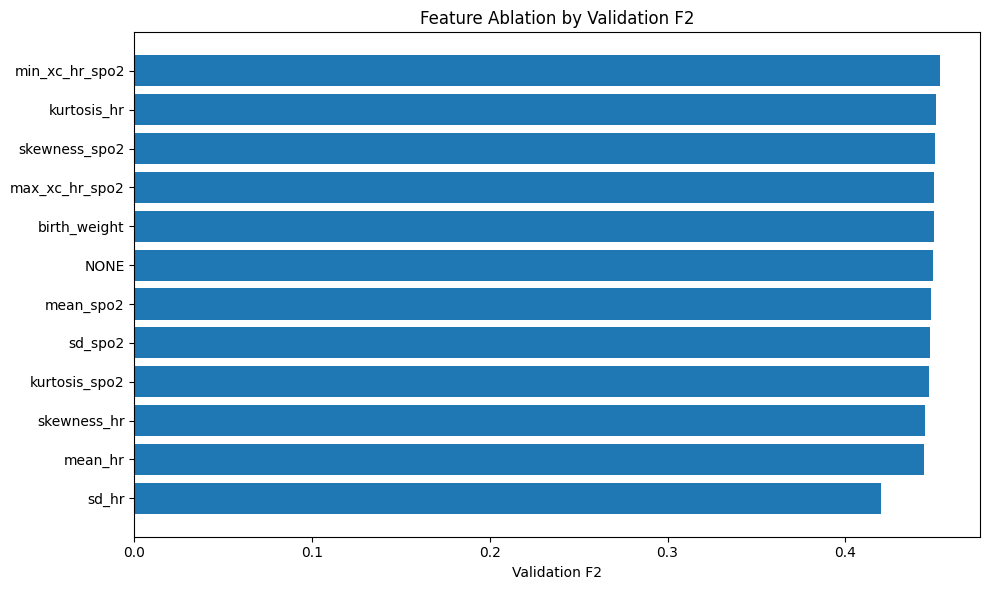

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(ablation_df["removed_feature"], ablation_df["f2"])
plt.gca().invert_yaxis()
plt.title("Feature Ablation by Validation F2")
plt.xlabel("Validation F2")
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "feature_ablation_f2.png"), dpi=150)
plt.show()

In [38]:
POSTPROCESSING_CONFIG = {
    "ema_alpha": 0.3,
    "k": 2,
    "n": 3,
    "refractory_steps": 3
}

save_json(POSTPROCESSING_CONFIG, os.path.join(BASE_OUTPUT_DIR, "postprocessing_config.json"))
print(json.dumps(POSTPROCESSING_CONFIG, indent=2))

{
  "ema_alpha": 0.3,
  "k": 2,
  "n": 3,
  "refractory_steps": 3
}


In [39]:
val_post_df = apply_ema_per_patient(val_pred_df, alpha=POSTPROCESSING_CONFIG["ema_alpha"])
val_post_df = apply_k_of_n_rule(val_post_df, prob_col="y_prob_ema", threshold=best_thr, k=POSTPROCESSING_CONFIG["k"], n=POSTPROCESSING_CONFIG["n"])
val_post_df = apply_refractory_period(val_post_df, refractory_steps=POSTPROCESSING_CONFIG["refractory_steps"])

test_post_df = apply_ema_per_patient(test_pred_df, alpha=POSTPROCESSING_CONFIG["ema_alpha"])
test_post_df = apply_k_of_n_rule(test_post_df, prob_col="y_prob_ema", threshold=best_thr, k=POSTPROCESSING_CONFIG["k"], n=POSTPROCESSING_CONFIG["n"])
test_post_df = apply_refractory_period(test_post_df, refractory_steps=POSTPROCESSING_CONFIG["refractory_steps"])

val_post_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "val_predictions_patientwise_postprocessed.csv"), index=False)
test_post_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "test_predictions_patientwise_postprocessed.csv"), index=False)

print("Postprocessed files saved.")

Postprocessed files saved.


In [40]:
val_metrics_post = compute_metrics_from_binary(
    y_true=val_post_df[TARGET_COL],
    y_pred=val_post_df["y_alert_final"],
    y_prob=val_post_df["y_prob_ema"]
)

test_metrics_post = compute_metrics_from_binary(
    y_true=test_post_df[TARGET_COL],
    y_pred=test_post_df["y_alert_final"],
    y_prob=test_post_df["y_prob_ema"]
)

save_json(val_metrics_post, os.path.join(BASE_OUTPUT_DIR, "val_metrics_window_level_postprocessed.json"))
save_json(test_metrics_post, os.path.join(BASE_OUTPUT_DIR, "test_metrics_window_level_postprocessed.json"))

metrics_table_post = pd.DataFrame([val_metrics_post, test_metrics_post], index=["Validation_Post", "Test_Post"])
display(metrics_table_post)

,accuracy,precision,recall,f1,f2,specificity,ppv,npv,tp,tn,fp,fn,roc_auc,pr_auc,brier
Validation_Post,0.797345,0.171819,0.206497,0.187569,0.198485,0.872834,0.171819,0.895937,1195,39535,5760,4592,0.713391,0.229740,0.193665
Test_Post,0.774293,0.203075,0.190836,0.196765,0.193164,0.873134,0.203075,0.864309,1466,39594,5753,6216,0.710963,0.306345,0.203389


In [41]:
patient_df_raw, patient_metrics_raw = patient_level_evaluation(test_pred_df, pred_col="y_pred", prob_col="y_prob")

patient_df_raw.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_level_predictions_test_raw.csv"), index=False)
save_json(patient_metrics_raw, os.path.join(BASE_OUTPUT_DIR, "patient_level_metrics_test_raw.json"))

display(pd.DataFrame([patient_metrics_raw]))

,n_patients,patient_sensitivity,patient_specificity,patient_ppv,patient_npv,patient_accuracy,tp,tn,fp,fn
0,66,0.954545,0.272727,0.396226,0.923077,0.5,21,12,32,1


In [42]:
patient_df_post, patient_metrics_post = patient_level_evaluation(test_post_df, pred_col="y_alert_final", prob_col="y_prob_ema")

patient_df_post.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_level_predictions_test_postprocessed.csv"), index=False)
save_json(patient_metrics_post, os.path.join(BASE_OUTPUT_DIR, "patient_level_metrics_test_postprocessed.json"))

display(pd.DataFrame([patient_metrics_post]))

,n_patients,patient_sensitivity,patient_specificity,patient_ppv,patient_npv,patient_accuracy,tp,tn,fp,fn
0,66,0.863636,0.454545,0.44186,0.869565,0.590909,19,20,24,3


In [43]:
first_alerts_raw = compute_first_alerts(test_pred_df, alert_col="y_pred")
alert_summary_raw = summarize_alerts(first_alerts_raw)

first_alerts_raw.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_first_alerts_test_raw.csv"), index=False)
save_json(alert_summary_raw, os.path.join(BASE_OUTPUT_DIR, "alert_summary_test_raw.json"))

display(pd.DataFrame([alert_summary_raw]))

,n_event_patients,n_detected_event_patients,event_detection_rate,median_lead_hours_detected,mean_lead_hours_detected
0,22,21,0.954545,257.333333,354.349206


In [44]:
first_alerts_post = compute_first_alerts(test_post_df, alert_col="y_alert_final")
alert_summary_post = summarize_alerts(first_alerts_post)

first_alerts_post.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_first_alerts_test_postprocessed.csv"), index=False)
save_json(alert_summary_post, os.path.join(BASE_OUTPUT_DIR, "alert_summary_test_postprocessed.json"))

display(pd.DataFrame([alert_summary_post]))

,n_event_patients,n_detected_event_patients,event_detection_rate,median_lead_hours_detected,mean_lead_hours_detected
0,22,19,0.863636,255.5,370.666667


In [45]:
calibrator = CalibratedClassifierCV(xgb_model, method="sigmoid", cv="prefit")
calibrator.fit(X_val_imp, y_val)

joblib.dump(calibrator, os.path.join(BASE_OUTPUT_DIR, "xgboost_calibrated_platt.pkl"))

cal_val_prob = calibrator.predict_proba(X_val_imp)[:, 1]
cal_test_prob = calibrator.predict_proba(X_test_imp)[:, 1]

cal_thr, cal_best_f2 = find_best_threshold(y_val, cal_val_prob)

calibration_info = {
    "method": "Platt Scaling / sigmoid",
    "best_threshold_after_calibration": cal_thr,
    "best_validation_f2_after_calibration": cal_best_f2
}

save_json(calibration_info, os.path.join(BASE_OUTPUT_DIR, "calibration_platt.json"))
print(json.dumps(calibration_info, indent=2))

{
  "method": "Platt Scaling / sigmoid",
  "best_threshold_after_calibration": 0.09,
  "best_validation_f2_after_calibration": 0.4489820169531807
}


In [46]:
val_metrics_cal = compute_metrics(y_val, cal_val_prob, threshold=cal_thr)
test_metrics_cal = compute_metrics(y_test, cal_test_prob, threshold=cal_thr)

save_json(val_metrics_cal, os.path.join(BASE_OUTPUT_DIR, "val_metrics_window_level_calibrated.json"))
save_json(test_metrics_cal, os.path.join(BASE_OUTPUT_DIR, "test_metrics_window_level_calibrated.json"))

metrics_table_cal = pd.DataFrame([val_metrics_cal, test_metrics_cal], index=["Validation_Cal", "Test_Cal"])
display(metrics_table_cal)

,threshold,accuracy,precision,recall,f1,f2,specificity,ppv,npv,roc_auc,pr_auc,brier,tp,tn,fp,fn
Validation_Cal,0.09,0.528934,0.165813,0.783480,0.273701,0.448982,0.496412,0.165813,0.947215,0.684426,0.193114,0.096379,4534,22485,22810,1253
Test_Cal,0.09,0.530842,0.202093,0.759307,0.319223,0.489420,0.492138,0.202093,0.923488,0.688949,0.262241,0.117584,5833,22317,23030,1849


In [47]:
cal_val_pred_df = make_prediction_df(val_df, cal_val_prob, cal_thr)
cal_test_pred_df = make_prediction_df(test_df, cal_test_prob, cal_thr)

cal_val_pred_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "val_predictions_patientwise_calibrated.csv"), index=False)
cal_test_pred_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "test_predictions_patientwise_calibrated.csv"), index=False)

print("Calibrated predictions saved.")

Calibrated predictions saved.


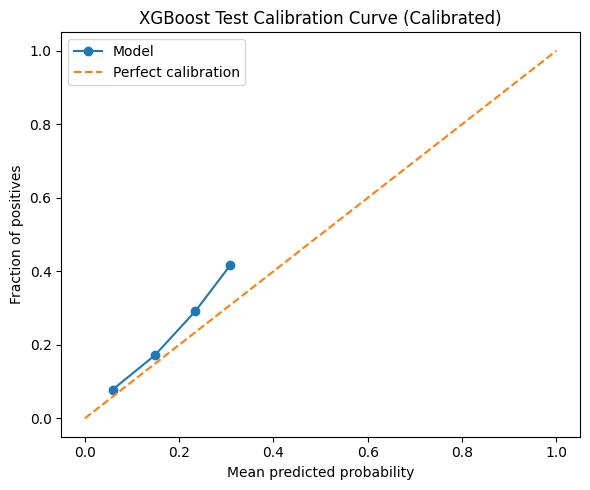

In [48]:
plot_calibration_curve(
    y_test, cal_test_prob,
    title="XGBoost Test Calibration Curve (Calibrated)",
    save_path=os.path.join(BASE_OUTPUT_DIR, "calibration_curve_test_calibrated.png")
)

In [49]:
cal_val_post_df = apply_ema_per_patient(cal_val_pred_df, alpha=POSTPROCESSING_CONFIG["ema_alpha"])
cal_val_post_df = apply_k_of_n_rule(cal_val_post_df, prob_col="y_prob_ema", threshold=cal_thr, k=POSTPROCESSING_CONFIG["k"], n=POSTPROCESSING_CONFIG["n"])
cal_val_post_df = apply_refractory_period(cal_val_post_df, refractory_steps=POSTPROCESSING_CONFIG["refractory_steps"])

cal_test_post_df = apply_ema_per_patient(cal_test_pred_df, alpha=POSTPROCESSING_CONFIG["ema_alpha"])
cal_test_post_df = apply_k_of_n_rule(cal_test_post_df, prob_col="y_prob_ema", threshold=cal_thr, k=POSTPROCESSING_CONFIG["k"], n=POSTPROCESSING_CONFIG["n"])
cal_test_post_df = apply_refractory_period(cal_test_post_df, refractory_steps=POSTPROCESSING_CONFIG["refractory_steps"])

cal_val_post_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "val_predictions_patientwise_calibrated_postprocessed.csv"), index=False)
cal_test_post_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "test_predictions_patientwise_calibrated_postprocessed.csv"), index=False)

print("Calibrated postprocessed files saved.")

Calibrated postprocessed files saved.


In [50]:
val_metrics_cal_post = compute_metrics_from_binary(
    y_true=cal_val_post_df[TARGET_COL],
    y_pred=cal_val_post_df["y_alert_final"],
    y_prob=cal_val_post_df["y_prob_ema"]
)

test_metrics_cal_post = compute_metrics_from_binary(
    y_true=cal_test_post_df[TARGET_COL],
    y_pred=cal_test_post_df["y_alert_final"],
    y_prob=cal_test_post_df["y_prob_ema"]
)

save_json(val_metrics_cal_post, os.path.join(BASE_OUTPUT_DIR, "val_metrics_window_level_calibrated_postprocessed.json"))
save_json(test_metrics_cal_post, os.path.join(BASE_OUTPUT_DIR, "test_metrics_window_level_calibrated_postprocessed.json"))

metrics_table_cal_post = pd.DataFrame([val_metrics_cal_post, test_metrics_cal_post], index=["Validation_Cal_Post", "Test_Cal_Post"])
display(metrics_table_cal_post)

,accuracy,precision,recall,f1,f2,specificity,ppv,npv,tp,tn,fp,fn,roc_auc,pr_auc,brier
Validation_Cal_Post,0.778219,0.154230,0.213582,0.179117,0.198318,0.850359,0.154230,0.894330,1236,38517,6778,4551,0.707251,0.225064,0.095239
Test_Cal_Post,0.758283,0.184753,0.195913,0.190169,0.193574,0.853552,0.184753,0.862376,1505,38706,6641,6177,0.706694,0.302308,0.116534


In [51]:
patient_df_cal, patient_metrics_cal = patient_level_evaluation(cal_test_pred_df, pred_col="y_pred", prob_col="y_prob")

patient_df_cal.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_level_predictions_test_calibrated.csv"), index=False)
save_json(patient_metrics_cal, os.path.join(BASE_OUTPUT_DIR, "patient_level_metrics_test_calibrated.json"))

display(pd.DataFrame([patient_metrics_cal]))

,n_patients,patient_sensitivity,patient_specificity,patient_ppv,patient_npv,patient_accuracy,tp,tn,fp,fn
0,66,0.954545,0.25,0.388889,0.916667,0.484848,21,11,33,1


In [52]:
patient_df_cal_post, patient_metrics_cal_post = patient_level_evaluation(cal_test_post_df, pred_col="y_alert_final", prob_col="y_prob_ema")

patient_df_cal_post.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_level_predictions_test_calibrated_postprocessed.csv"), index=False)
save_json(patient_metrics_cal_post, os.path.join(BASE_OUTPUT_DIR, "patient_level_metrics_test_calibrated_postprocessed.json"))

display(pd.DataFrame([patient_metrics_cal_post]))

,n_patients,patient_sensitivity,patient_specificity,patient_ppv,patient_npv,patient_accuracy,tp,tn,fp,fn
0,66,0.909091,0.409091,0.434783,0.9,0.575758,20,18,26,2


In [53]:
first_alerts_cal = compute_first_alerts(cal_test_pred_df, alert_col="y_pred")
alert_summary_cal = summarize_alerts(first_alerts_cal)

first_alerts_cal.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_first_alerts_test_calibrated.csv"), index=False)
save_json(alert_summary_cal, os.path.join(BASE_OUTPUT_DIR, "alert_summary_test_calibrated.json"))

display(pd.DataFrame([alert_summary_cal]))

,n_event_patients,n_detected_event_patients,event_detection_rate,median_lead_hours_detected,mean_lead_hours_detected
0,22,21,0.954545,258.166667,354.468254


In [54]:
first_alerts_cal_post = compute_first_alerts(cal_test_post_df, alert_col="y_alert_final")
alert_summary_cal_post = summarize_alerts(first_alerts_cal_post)

first_alerts_cal_post.to_csv(os.path.join(BASE_OUTPUT_DIR, "patient_first_alerts_test_calibrated_postprocessed.csv"), index=False)
save_json(alert_summary_cal_post, os.path.join(BASE_OUTPUT_DIR, "alert_summary_test_calibrated_postprocessed.json"))

display(pd.DataFrame([alert_summary_cal_post]))

,n_event_patients,n_detected_event_patients,event_detection_rate,median_lead_hours_detected,mean_lead_hours_detected
0,22,19,0.863636,257.333333,370.885965


Number of detected sepsis patients: 21
Mean lead time (hours): 330.3730158730159
Median lead time (hours): 233.33333333333334


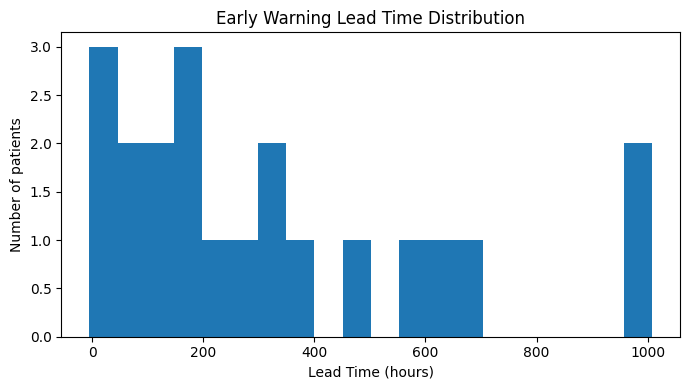

In [55]:
alerts = []

for pid, g in test_pred_df.groupby(PATIENT_COL):
    g = g.sort_values(TIME_COL)

    event_rows = g[g[TARGET_COL] == 1]
    alert_rows = g[g["y_pred"] == 1]

    if len(event_rows) > 0 and len(alert_rows) > 0:
        t_event = event_rows[TIME_COL].min()
        t_alert = alert_rows[TIME_COL].min()
        lead_hours = (t_event - t_alert) / 3600.0
        alerts.append(lead_hours)

alerts = pd.Series(alerts)

print("Number of detected sepsis patients:", len(alerts))
print("Mean lead time (hours):", alerts.mean())
print("Median lead time (hours):", alerts.median())

plt.figure(figsize=(7, 4))
plt.hist(alerts, bins=20)
plt.xlabel("Lead Time (hours)")
plt.ylabel("Number of patients")
plt.title("Early Warning Lead Time Distribution")
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "early_warning_histogram.png"), dpi=150)
plt.show()

,count
error_type,
correct,29484
False Positive,21530
False Negative,2015


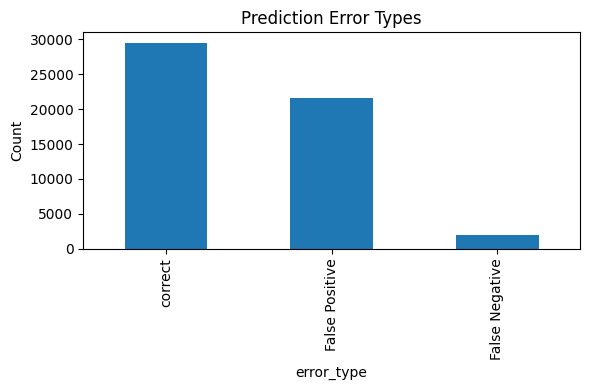

In [56]:
test_pred_df["error_type"] = "correct"

test_pred_df.loc[
    (test_pred_df[TARGET_COL] == 1) & (test_pred_df["y_pred"] == 0),
    "error_type"
] = "False Negative"

test_pred_df.loc[
    (test_pred_df[TARGET_COL] == 0) & (test_pred_df["y_pred"] == 1),
    "error_type"
] = "False Positive"

error_counts = test_pred_df["error_type"].value_counts()
display(error_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
error_counts.plot(kind="bar")
plt.title("Prediction Error Types")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(BASE_OUTPUT_DIR, "error_analysis_barplot.png"), dpi=150)
plt.show()

In [57]:
complexity_info = {
    "model_name": "XGBoost",
    "execution_device": "GPU",
    "gpu_mode": "cuda",
    "n_estimators": int(xgb_model.get_params()["n_estimators"]),
    "max_depth": int(xgb_model.get_params()["max_depth"]),
    "learning_rate": float(xgb_model.get_params()["learning_rate"]),
    "n_features": int(len(FEATURE_COLS)),
    "excluded_from_training_only": EXCLUDED_FROM_TRAINING,
    "train_time_seconds": float(train_time),
    "val_inference_time_seconds": float(val_inference_time),
    "test_inference_time_seconds": float(test_inference_time),
    "model_size_kb": float(model_size_kb),
    "train_rows": int(len(X_train_imp)),
    "val_rows": int(len(X_val_imp)),
    "test_rows": int(len(X_test_imp))
}

save_json(complexity_info, os.path.join(BASE_OUTPUT_DIR, "complexity_and_efficiency.json"))
display(pd.DataFrame([complexity_info]))

,model_name,execution_device,gpu_mode,n_estimators,max_depth,learning_rate,n_features,excluded_from_training_only,train_time_seconds,val_inference_time_seconds,test_inference_time_seconds,model_size_kb,train_rows,val_rows,test_rows
0,XGBoost,GPU,cuda,200,4,0.05,11,"[new_id, patient_label, seconds_since_birth, y...",1.213005,0.019935,0.013999,312.274414,45717,51082,53029


In [58]:
report_df = pd.DataFrame([
    {
        "Setting": "Raw",
        "Threshold": test_metrics_raw["threshold"],
        "Accuracy": test_metrics_raw["accuracy"],
        "Precision": test_metrics_raw["precision"],
        "Recall": test_metrics_raw["recall"],
        "F1": test_metrics_raw["f1"],
        "F2": test_metrics_raw["f2"],
        "Specificity": test_metrics_raw["specificity"],
        "PPV": test_metrics_raw["ppv"],
        "NPV": test_metrics_raw["npv"],
        "ROC_AUC": test_metrics_raw["roc_auc"],
        "PR_AUC": test_metrics_raw["pr_auc"],
        "Brier": test_metrics_raw["brier"],
        "Patient_Sensitivity": patient_metrics_raw["patient_sensitivity"],
        "Patient_Specificity": patient_metrics_raw["patient_specificity"],
        "Detection_Rate": alert_summary_raw["event_detection_rate"],
        "Median_Lead_Hours": alert_summary_raw["median_lead_hours_detected"]
    },
    {
        "Setting": "Postprocessed",
        "Threshold": best_thr,
        "Accuracy": test_metrics_post["accuracy"],
        "Precision": test_metrics_post["precision"],
        "Recall": test_metrics_post["recall"],
        "F1": test_metrics_post["f1"],
        "F2": test_metrics_post["f2"],
        "Specificity": test_metrics_post["specificity"],
        "PPV": test_metrics_post["ppv"],
        "NPV": test_metrics_post["npv"],
        "ROC_AUC": test_metrics_post["roc_auc"],
        "PR_AUC": test_metrics_post["pr_auc"],
        "Brier": test_metrics_post["brier"],
        "Patient_Sensitivity": patient_metrics_post["patient_sensitivity"],
        "Patient_Specificity": patient_metrics_post["patient_specificity"],
        "Detection_Rate": alert_summary_post["event_detection_rate"],
        "Median_Lead_Hours": alert_summary_post["median_lead_hours_detected"]
    },
    {
        "Setting": "Calibrated",
        "Threshold": test_metrics_cal["threshold"],
        "Accuracy": test_metrics_cal["accuracy"],
        "Precision": test_metrics_cal["precision"],
        "Recall": test_metrics_cal["recall"],
        "F1": test_metrics_cal["f1"],
        "F2": test_metrics_cal["f2"],
        "Specificity": test_metrics_cal["specificity"],
        "PPV": test_metrics_cal["ppv"],
        "NPV": test_metrics_cal["npv"],
        "ROC_AUC": test_metrics_cal["roc_auc"],
        "PR_AUC": test_metrics_cal["pr_auc"],
        "Brier": test_metrics_cal["brier"],
        "Patient_Sensitivity": patient_metrics_cal["patient_sensitivity"],
        "Patient_Specificity": patient_metrics_cal["patient_specificity"],
        "Detection_Rate": alert_summary_cal["event_detection_rate"],
        "Median_Lead_Hours": alert_summary_cal["median_lead_hours_detected"]
    },
    {
        "Setting": "Calibrated_Postprocessed",
        "Threshold": cal_thr,
        "Accuracy": test_metrics_cal_post["accuracy"],
        "Precision": test_metrics_cal_post["precision"],
        "Recall": test_metrics_cal_post["recall"],
        "F1": test_metrics_cal_post["f1"],
        "F2": test_metrics_cal_post["f2"],
        "Specificity": test_metrics_cal_post["specificity"],
        "PPV": test_metrics_cal_post["ppv"],
        "NPV": test_metrics_cal_post["npv"],
        "ROC_AUC": test_metrics_cal_post["roc_auc"],
        "PR_AUC": test_metrics_cal_post["pr_auc"],
        "Brier": test_metrics_cal_post["brier"],
        "Patient_Sensitivity": patient_metrics_cal_post["patient_sensitivity"],
        "Patient_Specificity": patient_metrics_cal_post["patient_specificity"],
        "Detection_Rate": alert_summary_cal_post["event_detection_rate"],
        "Median_Lead_Hours": alert_summary_cal_post["median_lead_hours_detected"]
    }
])

report_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "final_report_table.csv"), index=False)
display(report_df)

,Setting,Threshold,Accuracy,Precision,Recall,F1,F2,Specificity,PPV,NPV,ROC_AUC,PR_AUC,Brier,Patient_Sensitivity,Patient_Specificity,Detection_Rate,Median_Lead_Hours
0,Raw,0.40,0.555998,0.208369,0.737699,0.324952,0.489167,0.525217,0.208369,0.921996,0.688949,0.262241,0.214233,0.954545,0.272727,0.954545,257.333333
1,Postprocessed,0.40,0.774293,0.203075,0.190836,0.196765,0.193164,0.873134,0.203075,0.864309,0.710963,0.306345,0.203389,0.863636,0.454545,0.863636,255.500000
2,Calibrated,0.09,0.530842,0.202093,0.759307,0.319223,0.489420,0.492138,0.202093,0.923488,0.688949,0.262241,0.117584,0.954545,0.250000,0.954545,258.166667
3,Calibrated_Postprocessed,0.09,0.758283,0.184753,0.195913,0.190169,0.193574,0.853552,0.184753,0.862376,0.706694,0.302308,0.116534,0.909091,0.409091,0.863636,257.333333


In [59]:
final_summary = {
    "raw_window_level": test_metrics_raw,
    "postprocessed_window_level": test_metrics_post,
    "calibrated_window_level": test_metrics_cal,
    "calibrated_postprocessed_window_level": test_metrics_cal_post,
    "raw_patient_level": patient_metrics_raw,
    "postprocessed_patient_level": patient_metrics_post,
    "calibrated_patient_level": patient_metrics_cal,
    "calibrated_postprocessed_patient_level": patient_metrics_cal_post,
    "raw_alert_summary": alert_summary_raw,
    "postprocessed_alert_summary": alert_summary_post,
    "calibrated_alert_summary": alert_summary_cal,
    "calibrated_postprocessed_alert_summary": alert_summary_cal_post,
    "threshold_info_raw": threshold_info,
    "threshold_info_calibrated": calibration_info,
    "complexity_and_efficiency": complexity_info
}

save_json(final_summary, os.path.join(BASE_OUTPUT_DIR, "FINAL_SUMMARY_XGBOOST.json"))
print("Final summary JSON saved.")

Final summary JSON saved.


In [60]:
print("=" * 100)
print("Notebook finished successfully.")
print("Outputs saved to:")
print(BASE_OUTPUT_DIR)
print("=" * 100)

Notebook finished successfully.
Outputs saved to:
C:\Users\User\Desktop\Data\sepsis_xgboost_lujain
